# ORU HACKATHON

## From Dots to Damage - How IPL Batsmen Eliminated Dead Balls

In this notebook, we explore how IPL batting has changed over 18 seasons (2007-2025) using ball-by ball data. The central question is, has the way batsmen score fundamentally shifted, and if so, did it come at a cost?

### Loading the libraries and data. We use two CSV files, deliveries (every ball bowled) and matches (match-level info like season, venue, winner)

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [60]:
# reading data from csv files
deliveries = pd.read_csv("deliveries_updated_ipl_upto_2025.csv")
matches = pd.read_csv("matches_updated_ipl_upto_2025.csv")

In [61]:
# Displaying first few rows of the data for inspection
deliveries.head()

,matchId,inning,over_ball,over,ball,batting_team,bowling_team,batsman,non_striker,bowler,batsman_runs,extras,isWide,isNoBall,Byes,LegByes,Penalty,dismissal_kind,player_dismissed,date
0,335982,1,0.1,0,1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,P Kumar,0,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,2008-04-18
1,335982,1,0.2,0,2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18
2,335982,1,0.3,0,3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18
3,335982,1,0.4,0,4,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18
4,335982,1,0.5,0,5,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18


In [62]:
# Printing shapes of data to be used
print(f"Deliveries: {deliveries.shape}")
print(f"Matches: {matches.shape}")

Deliveries: (278205, 20)
Matches: (1169, 28)


In [81]:
# Identifying the score which boundary score that is either four or six
fours = (deliveries['batsman_runs'] == 4).sum()
sixes = (deliveries['batsman_runs'] == 6).sum()
print(f"Total 4s hit: {fours:,}")
print(f"Total 6s hit: {sixes:,}")
print(f"Ratio of 4s to 6s: {fours/sixes:.1f}")  # Ratio = 4/6

Total 4s hit: 32,113
Total 6s hit: 14,353
Ratio of 4s to 6s: 2.2


**Data Preparation -** The deliveries table has ball-by-ball data but no season column. The matches table has seasons but no ball-by-ball detail. We merge them on matchId so every delivery knows which season it belongs to. 

In [64]:
deliveries_m = deliveries.merge(matches[['matchId', 'season']], on='matchId')

**Feature Engineering**
We create a few helper columns that we'll use throughout the analysis:
- **total_runs** - batsmans runs + extras for each ball
- **over_num** - the over column is zero-indexed (0 = first over), so we add 1
- **phase** - which part of the innings: Powerplay (1-6), Middle (7-15) or Death (16-20)
- **era** - splitting the 18 seasons into Early (2007-2015) and Recent (2016-2025) for comparison.

## Finding 1: Sixes vs Fours - Has the type of scoring changed?
The simplest question to start with is how many fours and sixes are hit per match each season? If batting has changed, this is where it should show up first.

In [65]:
# Calculating sixes scored per season
sixes_by_season = deliveries_m[deliveries_m['batsman_runs'] == 6].groupby('season').size()
matches_by_season = matches['season'].value_counts().sort_index()
sixes_per_match = (sixes_by_season / matches_by_season).sort_index()
print(sixes_per_match)

season
2007/08    10.741379
2009        8.912281
2009/10     9.783333
2011        8.753425
2012        9.905405
2013        8.960526
2014       11.916667
2015       11.728814
2016       10.650000
2017       11.966102
2018       14.533333
2019       13.100000
2020/21    12.266667
2021       11.450000
2022       14.351351
2023       15.189189
2024       17.760563
2025       17.594595
dtype: float64


In [66]:
# Calculting fours scored per season
fours_by_season = deliveries_m[deliveries_m['batsman_runs'] == 4].groupby('season').size()
fours_per_match = (fours_by_season / matches_by_season).sort_index()
ratio = fours_by_season / sixes_by_season
print("Fours per match:")
print(fours_per_match)

Fours per match:
season
2007/08    29.362069
2009       23.175439
2009/10    28.483333
2011       26.246575
2012       25.824324
2013       27.026316
2014       26.050000
2015       27.305085
2016       27.216667
2017       27.322034
2018       27.533333
2019       27.583333
2020/21    26.483333
2021       25.850000
2022       27.297297
2023       29.391892
2024       30.633803
2025       30.581081
dtype: float64


## Sixes nearly doubled - fours stayled flat

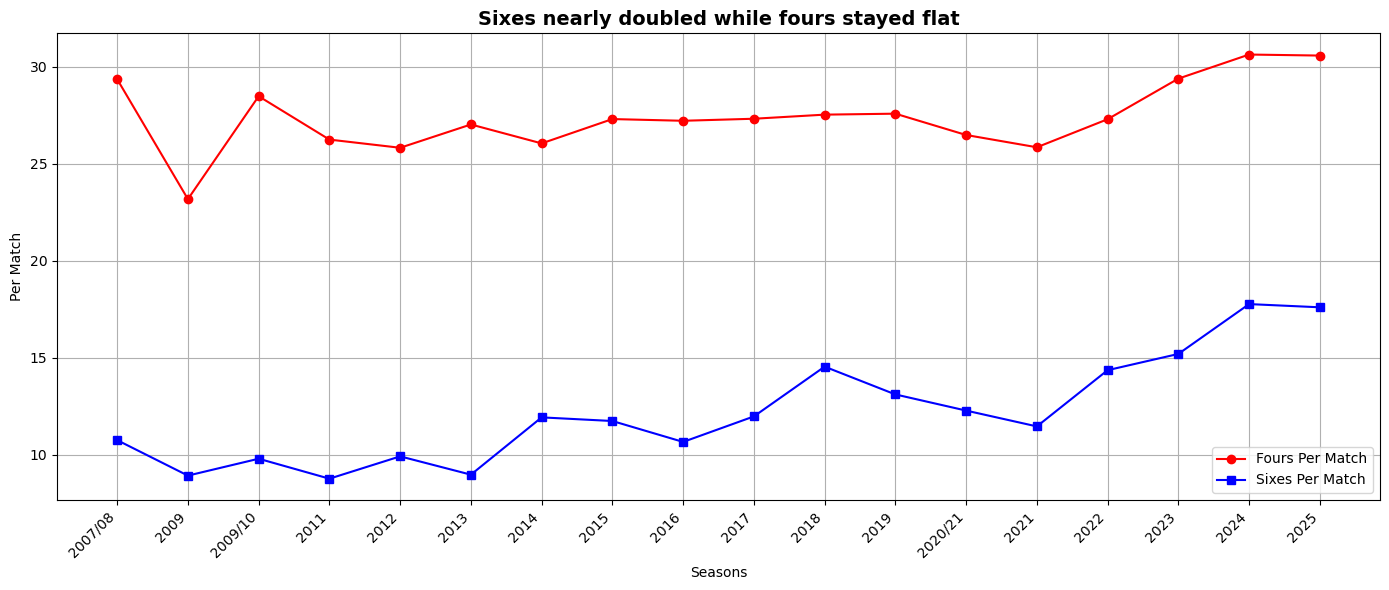

In [67]:
fig, ax = plt.subplots(figsize=(14, 6))
seasons = range(len(sixes_per_match))
seasons_label = sixes_per_match.index
ax.plot(seasons, fours_per_match, marker = 'o', label = 'Fours Per Match', c = 'red')
ax.plot(seasons, sixes_per_match, marker = 's', label = 'Sixes Per Match', c = 'blue')
ax.set_xticks(seasons)
ax.set_xticklabels(seasons_label, rotation=45, ha = 'right')
ax.set_xlabel('Seasons')
ax.set_ylabel('Per Match')
ax.set_title('Sixes nearly doubled while fours stayed flat', fontsize = 14, fontweight = 'bold')
ax.grid()
ax.legend()
plt.tight_layout()
plt.savefig('01_sixes_vs_fours_per_match.png', dpi = 150)
plt.show()

## Finding 2 The Fours-to-Sixes Ratio
Sixes doubled but fours didn't. So the ratio between them must have changed. Let's see how many fours were hit for every six, season by season

In [68]:
ratio = fours_by_season / sixes_by_season
print(f"\nFours-to-sixes ratio by season:")
print((ratio).sort_index().round(2))


Fours-to-sixes ratio by season:
season
2007/08    2.73
2009       2.60
2009/10    2.91
2011       3.00
2012       2.61
2013       3.02
2014       2.19
2015       2.33
2016       2.56
2017       2.28
2018       1.89
2019       2.11
2020/21    2.16
2021       2.26
2022       1.90
2023       1.94
2024       1.72
2025       1.74
dtype: float64


In [69]:
print('Minimum Ratio value', np.min(ratio))
print('Maximum Ratio value', np.max(ratio))

Minimum Ratio value 1.724821570182395
Maximum Ratio value 3.016152716593245


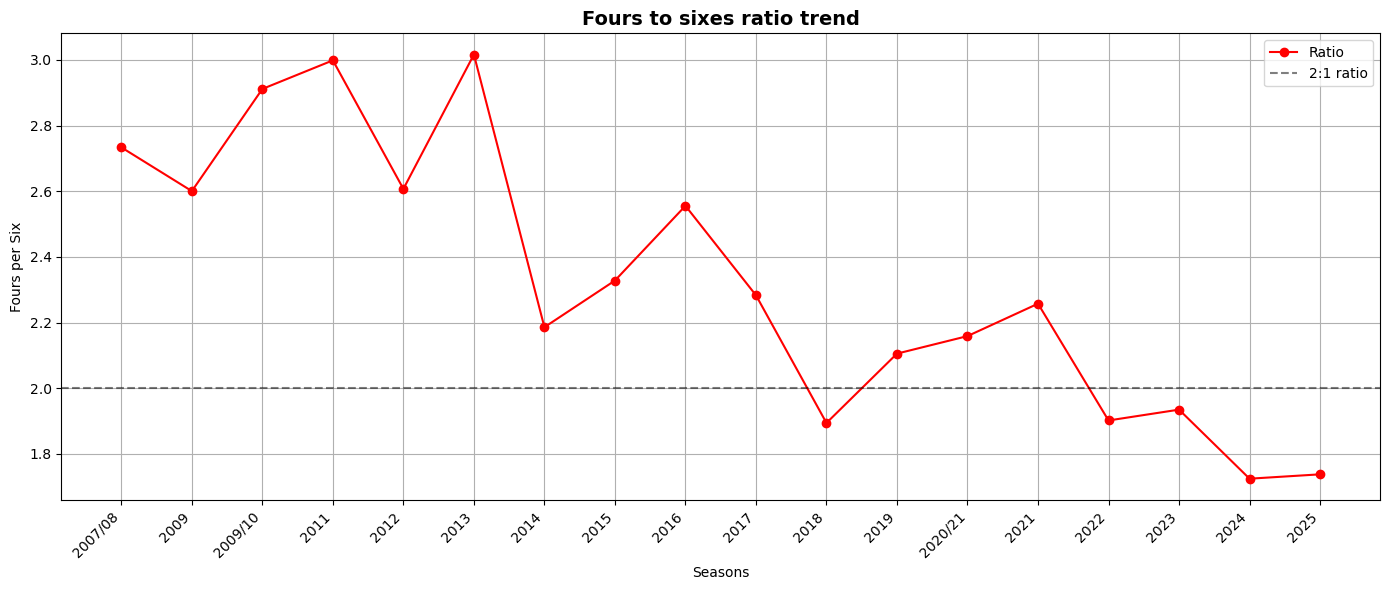

In [70]:
fig, ax = plt.subplots(figsize=(14, 6))
seasons = range(len(ratio))
seasons_label = ratio.index
ax.plot(seasons, ratio, marker = 'o', label = 'Ratio', c = 'red')
ax.axhline(y=2, linestyle='--', color = 'black', alpha = 0.5, label = '2:1 ratio')
ax.set_xticks(seasons)
ax.set_xticklabels(seasons_label, rotation=45, ha = 'right')
ax.set_xlabel('Seasons')
ax.set_ylabel('Fours per Six')
ax.set_title('Fours to sixes ratio trend', fontsize = 14, fontweight = 'bold')
ax.grid()
ax.legend()
plt.tight_layout()
plt.savefig('02_ratio_fours_vs_sixes_per_season.png', dpi = 150)
plt.show()

## Finding 3: Where did the extra runs come from?
If batsmen are hitting more sixes but not more fours, something else must have decreased. Let's look at what percentage of balls result in dots, singles, fours, sixes and compare the early era to the recent era. 

In [71]:
deliveries_m['over_num'] = deliveries_m['over'] + 1  # overs start from 1 to 20
def get_phase(over_num):
    if over_num <= 6:
        return '1. Powerplay (1-6 over)'
    elif over_num <= 15:
        return '2. Middle (7-15 over)'
    else:
        return '3. Death (16-20 over)'

deliveries_m['phase'] = deliveries_m['over_num'].apply(get_phase)
deliveries_m['era'] = deliveries_m['season'].apply(lambda x: 'Early (2007-2015)' if x in ['2007/8','2009', '2010', '2011', '2012', '2013', '2014', '2015'] 
                                                   else 'Recent (2016-2025)'
)

dots = deliveries_m.groupby(['era', 'phase']).apply(lambda x: (x['batsman_runs'] == 0).mean() * 100, include_groups = False)
dots_table = dots.unstack('era')
print(dots_table.columns.tolist())

['Early (2007-2015)', 'Recent (2016-2025)']


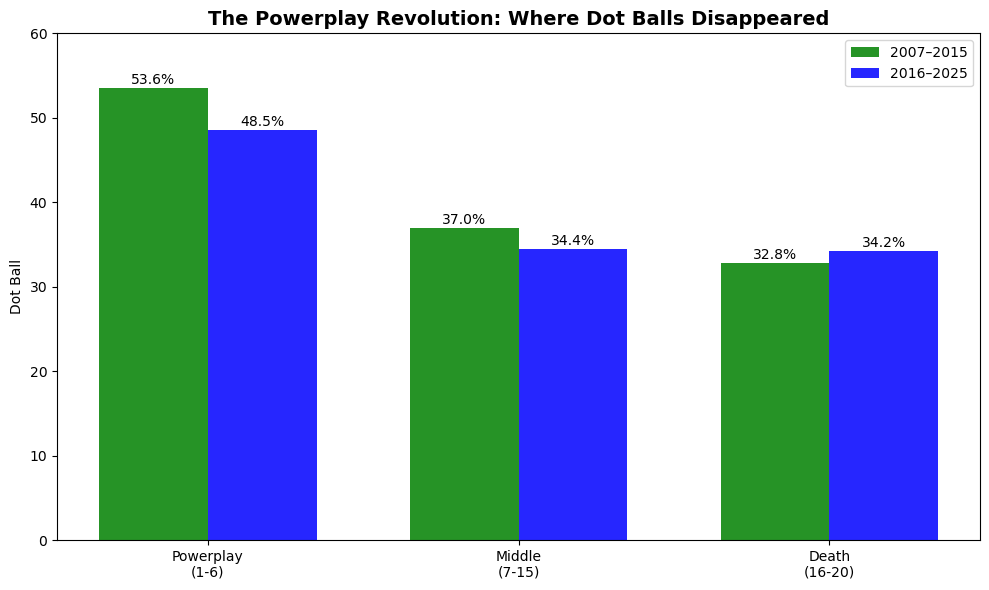

In [72]:
phases = ['Powerplay\n(1-6)', 'Middle\n(7-15)', 'Death\n(16-20)']
early_dots = dots_table['Early (2007-2015)'].values
recent_dots = dots_table['Recent (2016-2025)'].values

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(phases))

width = 0.35
bars1 = ax.bar(x - width/2, early_dots, width, label='2007–2015', color='green', alpha=0.85)
bars2 = ax.bar(x + width/2, recent_dots, width, label='2016–2025', color='blue', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10)

ax.set_ylabel('Dot Ball')
ax.set_title('The Powerplay Revolution: Where Dot Balls Disappeared', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(phases)
ax.legend()
ax.set_ylim(0, 60)

plt.tight_layout()
plt.savefig('03_powerplay_dot_ball_revolution.png', dpi=150)
plt.show()

## Finding 4: The powerplay (1-6 over) Transformation
The previous chart showed the powerplay has the biggest dot ball drop. Let's zoom in and track the powerplay season by season, plotting dot ball % and six % together to see exactly when the shift happened.

In [73]:
pp = deliveries_m[deliveries_m['phase'] == '1. Powerplay (1-6 over)']

pp_dots = pp.groupby('season').apply(
    lambda x: (x['batsman_runs'] == 0).mean() * 100, 
    include_groups = False)
pp_sixes = pp.groupby('season').apply(
    lambda x: (x['batsman_runs'] == 6).mean() * 100, 
    include_groups = False)

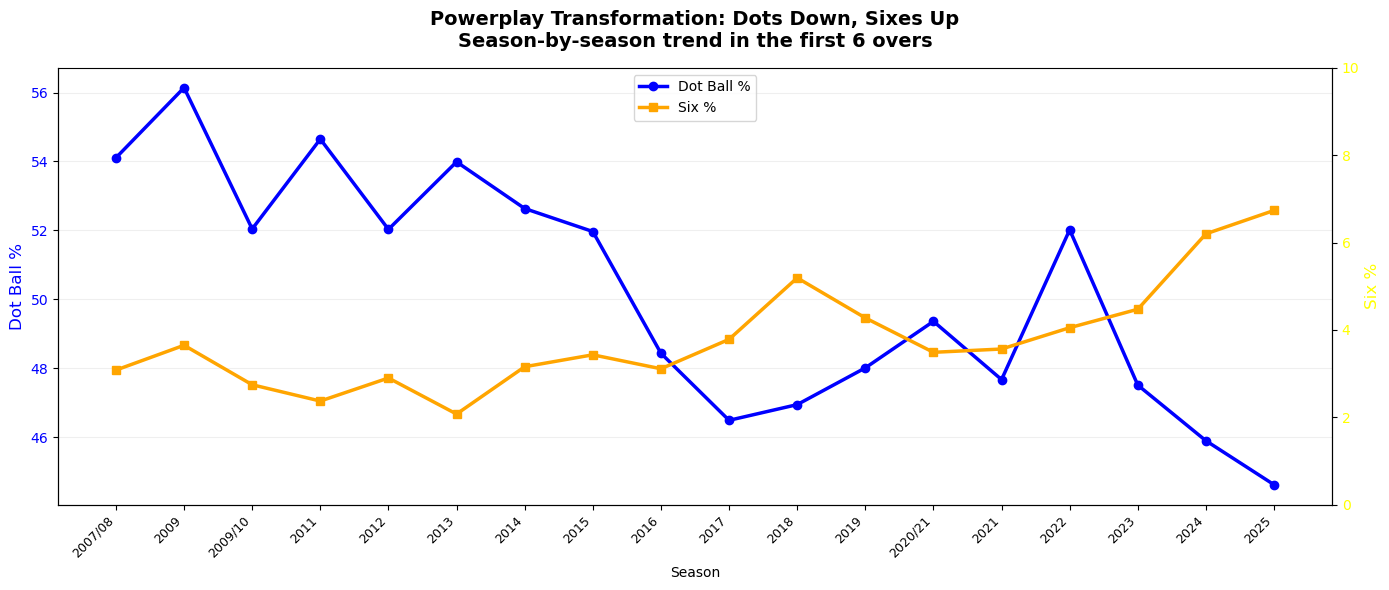

In [74]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(range(len(pp_dots)), pp_dots.values, color='blue', linewidth=2.5, 
         marker='o', markersize=6, label='Dot Ball %')
ax1.set_ylabel('Dot Ball %', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')


ax2 = ax1.twinx()
ax2.plot(range(len(pp_sixes)), pp_sixes.values, color='orange', linewidth=2.5,
         marker='s', markersize=6, label='Six %')
ax2.set_ylabel('Six %', color='yellow', fontsize=12)
ax2.tick_params(axis='y', labelcolor='yellow')
ax2.set_ylim(0, 10)

# X axis labels
ax1.set_xticks(range(len(pp_dots)))
ax1.set_xticklabels(pp_dots.index, rotation=45, ha='right', fontsize=9)
ax1.set_xlabel('Season')

# Title
ax1.set_title('Powerplay Transformation: Dots Down, Sixes Up\nSeason-by-season trend in the first 6 overs',
              fontsize=14, fontweight='bold', pad=15)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center')

ax1.spines['top'].set_visible(False)
ax1.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('04_powerplay_dots_vs_sixes.png', dpi = 150)
plt.show()

## Finding 5: Runs Per over by Phase
Are all three phases scoring more, or just the powerplay? Lets compare the runs per over across powerplay, middle, and death over for every season.

In [75]:
deliveries_m['total_runs'] = deliveries_m['batsman_runs'] + deliveries_m['extras']
avg_run = deliveries_m.groupby(['season','phase'])['total_runs'].mean()
avg_runs_table = avg_run.unstack('phase')
print(avg_runs_table.columns.tolist())
avg_rpo_table = avg_runs_table * 6

['1. Powerplay (1-6 over)', '2. Middle (7-15 over)', '3. Death (16-20 over)']


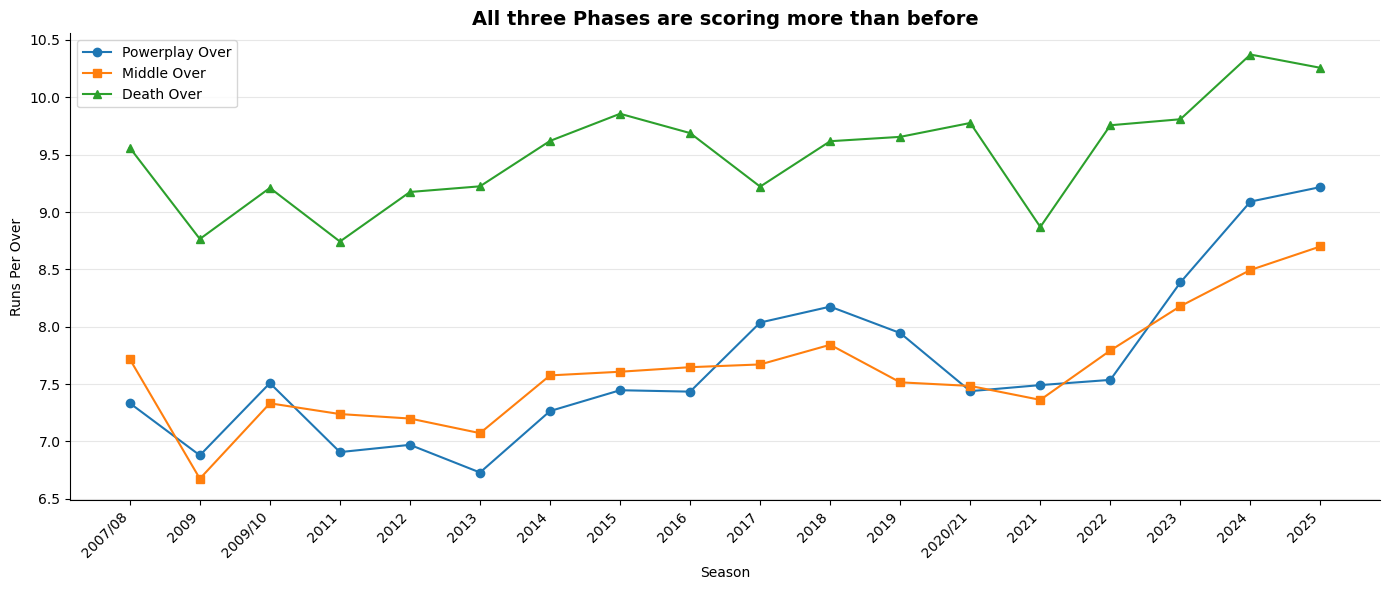

In [76]:
fig, ax = plt.subplots(figsize=(14, 6))

seasons = range(len(avg_rpo_table))
season_labels = avg_rpo_table.index

ax.plot(seasons, avg_rpo_table['1. Powerplay (1-6 over)'], marker='o', label='Powerplay Over')
ax.plot(seasons, avg_rpo_table['2. Middle (7-15 over)'], marker='s', label='Middle Over')
ax.plot(seasons, avg_rpo_table['3. Death (16-20 over)'], marker='^', label='Death Over')

ax.set_xticks(seasons)
ax.set_xticklabels(season_labels, rotation=45, ha='right')
ax.set_xlabel('Season')
ax.set_ylabel('Runs Per Over')
ax.set_title('All three Phases are scoring more than before', fontsize=14, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('05_runs_per_over_by_phase.png', dpi=150)
plt.show()

## Finding 6: Boundary % by Over, Early vs Recent Era
Which specific overs saw the biggest change in boundary hitting? Let's compare every over (1-20) between two eras.

In [77]:
fours_by_over = deliveries_m[deliveries_m['batsman_runs'] == 4].groupby(['era', 'over_num']).size()
total_by_over = deliveries_m.groupby(['era', 'over_num']).size()
four_pct = (fours_by_over / total_by_over * 100).round(1)
sixes_by_over = deliveries_m[deliveries_m['batsman_runs'] == 6].groupby(['era', 'over_num']).size()
total_by_over = deliveries_m.groupby(['era', 'over_num']).size()
six_pct = (sixes_by_over / total_by_over * 100).round(1)
boundary_pct = (four_pct + six_pct).unstack('era')
print(boundary_pct)

era       Early (2007-2015)  Recent (2016-2025)
over_num                                       
1                      12.9                14.6
2                      15.6                18.8
3                      18.0                21.8
4                      18.6                22.4
5                      18.6                22.5
6                      19.3                21.9
7                      10.0                11.1
8                      11.3                12.7
9                      11.7                14.1
10                     10.8                13.9
11                     12.7                14.4
12                     13.0                14.5
13                     12.7                14.7
14                     13.6                15.5
15                     15.2                17.0
16                     15.5                16.9
17                     17.5                18.6
18                     18.7                20.3
19                     19.3             

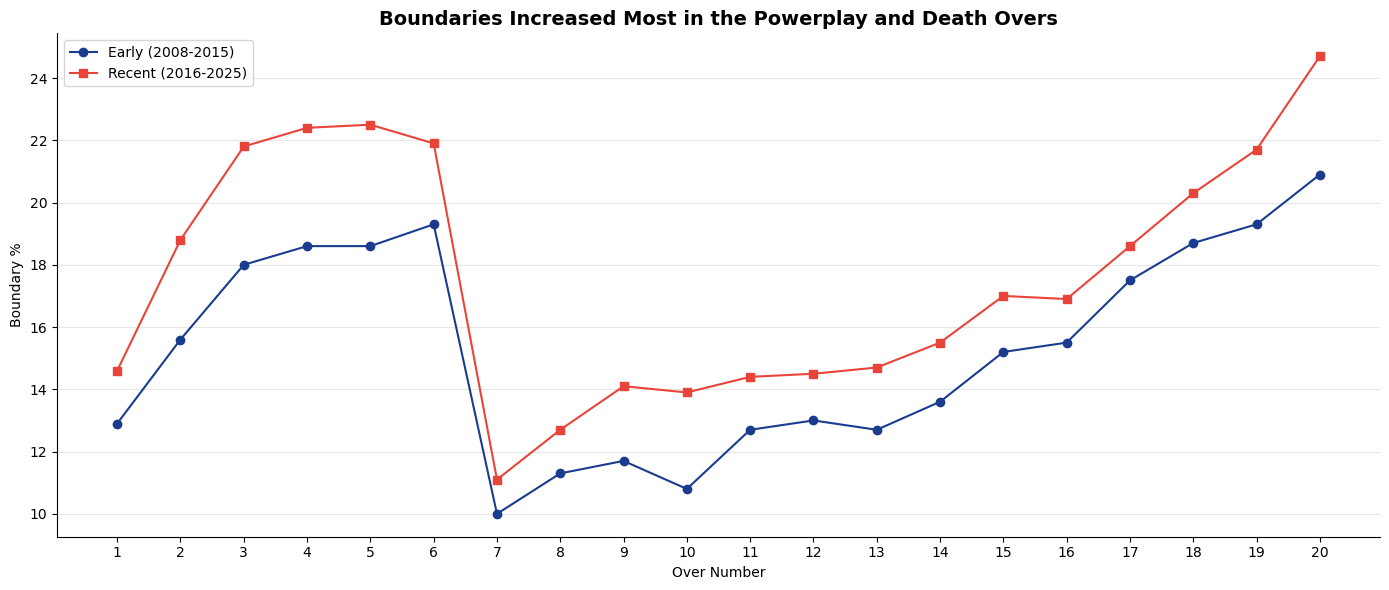

In [78]:
fig, ax = plt.subplots(figsize=(14, 6))

overs = boundary_pct.index  

ax.plot(overs, boundary_pct['Early (2007-2015)'], marker='o', label='Early (2008-2015)', color='#1A3C8F')
ax.plot(overs, boundary_pct['Recent (2016-2025)'], marker='s', label='Recent (2016-2025)', color='#E8443A')

ax.set_xticks(range(1,21))
ax.set_xlabel('Over Number')
ax.set_ylabel('Boundary %')
ax.set_title('Boundaries Increased Most in the Powerplay and Death Overs', fontsize=14, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('06_boundary_pct_by_over.png', dpi=150)
plt.show()

## Finding 7: The Boundary heatmap - 18 Years in one image
Let's put all 18 seasons and all 20 overs into a single heatmap. Each cell shows that boundary percentage for that over in that season. Darker red = more boundaries.

In [79]:
heatmap_data = deliveries_m.groupby(['season', 'over_num']).apply(
    lambda x: (x['batsman_runs'].isin([4, 6])).mean() * 100,
    include_groups=False
)

# Reshape: seasons as rows, overs as columns
heatmap_table = heatmap_data.unstack('over_num')

print(heatmap_table.round(1))

over_num    1     2     3     4     5     6     7     8     9     10    11  \
season                                                                       
2007/08   12.8  19.3  16.9  20.0  23.0  21.3  11.8  12.1  13.9  14.0  16.3   
2009      12.4  15.3  16.2  17.2  19.4  18.9   8.1   8.6  10.5   7.8   8.9   
2009/10   15.0  20.7  18.4  21.3  20.9  18.5  11.9  10.5  12.1  12.1  12.0   
2011      13.9  15.5  19.1  16.2  17.7  19.0   8.9  14.2  12.7  12.1  13.0   
2012      12.1  14.6  16.9  20.0  16.9  20.4  10.4  11.3  11.1  10.4  13.2   
2013      11.2  15.2  16.9  17.2  19.5  19.4  10.6  11.6  11.6  10.0  12.7   
2014      14.8  15.3  17.6  20.6  17.6  20.1  10.4  10.4  10.0  11.8  14.9   
2015      12.9  17.5  21.8  21.2  21.2  17.4  11.3  11.0  14.6  12.9  12.9   
2016      12.5  15.9  18.9  22.8  19.1  18.6   9.6  12.6  12.6  11.5  10.9   
2017      15.2  18.9  23.0  19.0  21.4  23.8   9.8  10.9  14.0  12.5  13.6   
2018      14.8  20.5  23.2  23.0  22.4  22.2  11.4  12.9  14.0  

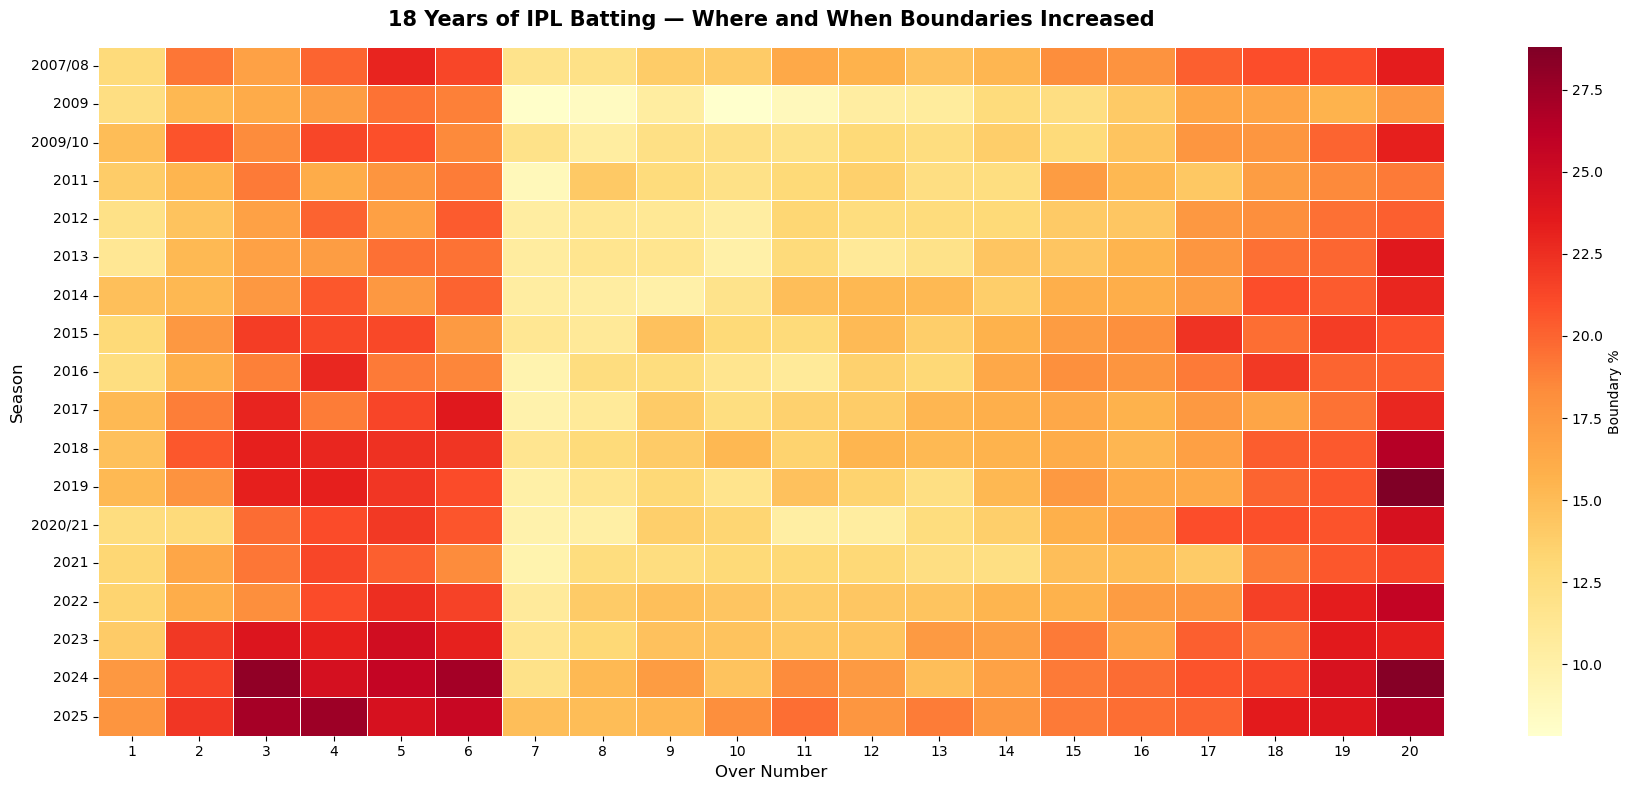

In [80]:
fig, ax = plt.subplots(figsize=(18, 8))

sns.heatmap(heatmap_table, cmap='YlOrRd', annot=False, linewidths=0.5,
            linecolor='white', ax=ax, cbar_kws={'label': 'Boundary %'})

ax.set_xlabel('Over Number', fontsize=12)
ax.set_ylabel('Season', fontsize=12)
ax.set_title('18 Years of IPL Batting — Where and When Boundaries Increased',
             fontsize=15, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('07_boundary_heatmap.png', dpi=150)
plt.show()

## Finding 8: Did Aggression Come at a Cost?
We have shown that batting got much more aggressive. The natural follow-up is **"Are batsmen getting out more often?"** If aggression has a cost, dismissals per match should be going up.

In [24]:
dismissals_per_match = deliveries_m[deliveries_m['dismissal_kind'].notna()].groupby('season').size()
matches_per_season = matches['season'].value_counts().sort_index()
dismissals_rate = (dismissals_per_match / matches_per_season).sort_index()
print(dismissals_rate)

season
2007/08    11.896552
2009       12.245614
2009/10    12.083333
2011       11.136986
2012       11.594595
2013       12.000000
2014       11.233333
2015       11.711864
2016       11.100000
2017       12.050847
2018       12.033333
2019       11.416667
2020/21    11.283333
2021       11.950000
2022       12.324324
2023       12.378378
2024       12.436620
2025       11.797297
dtype: float64


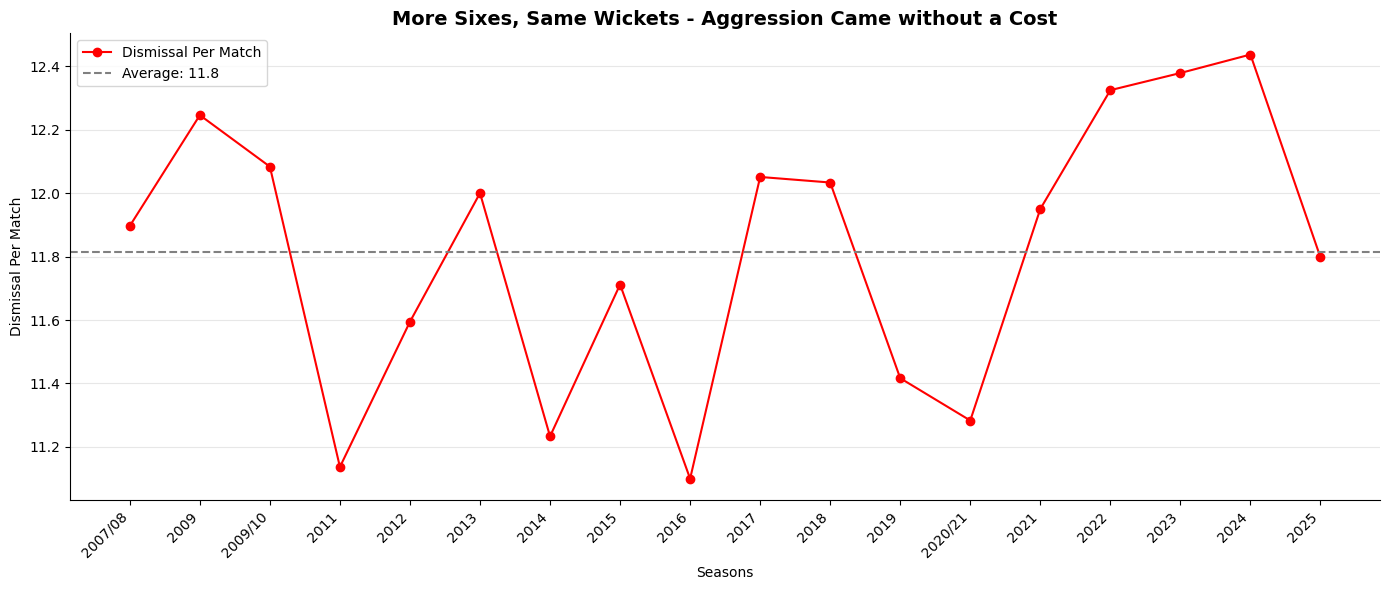

In [25]:
fig, ax = plt.subplots(figsize=(14, 6))

seasons1 = range(len(dismissals_rate))
season_labels = dismissals_rate.index
ax.plot(seasons1, dismissals_rate, marker='o', label='Dismissal Per Match', color='red')
avg = dismissals_rate.mean()
ax.axhline(y=avg, linestyle='--', color='gray', label = f'Average: {avg:.1f}')
ax.set_xticks(seasons1)
ax.set_xticklabels(season_labels, rotation = 45, ha = 'right')
ax.set_xlabel('Seasons')
ax.set_ylabel('Dismissal Per Match')
ax.set_title('More Sixes, Same Wickets - Aggression Came without a Cost', fontsize=14, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('08_dismissals_per_match.png', dpi=150)
plt.show()

## Finding 9: Sixes bars vs Dissmissals - Side by Side
Let's overlay the two metrics on one chart to make the contrast visual. Bars for sixes, line for dismissals.

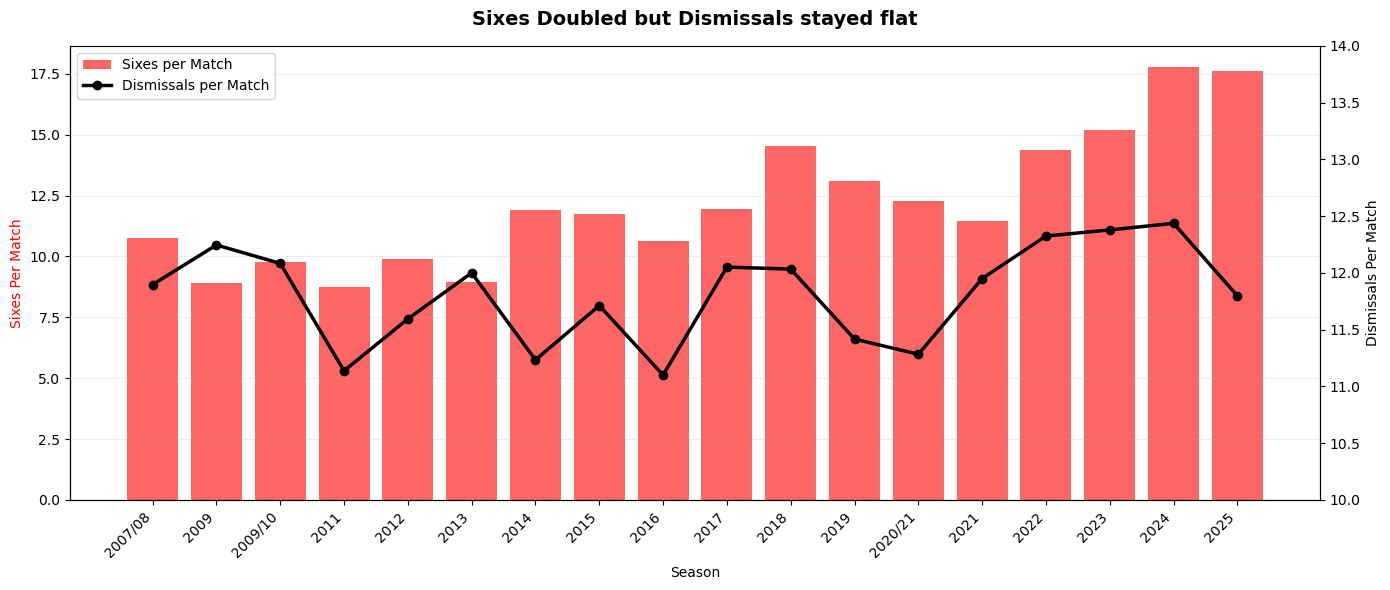

In [26]:
fig, ax1 = plt.subplots(figsize = (14, 6))
seasons = range(len(sixes_per_match))
seasons_labels = sixes_per_match.index

ax1.bar(seasons, sixes_per_match.values, color = 'red', alpha = 0.6, label = 'Sixes per Match')
ax1.set_ylabel('Sixes Per Match', c = 'red')

ax2 = ax1.twinx()
ax2.plot(seasons, dismissals_rate.values , c = 'black', linewidth = 2.5, marker = 'o', label = 'Dismissals per Match')
ax2.set_ylabel('Dismissals Per Match', c = 'black')
ax2.set_ylim(10, 14)

ax1.set_xticks(seasons)
ax1.set_xticklabels(seasons_labels, rotation = 45, ha= 'right')
ax1.set_xlabel('Season')
ax1.set_title('Sixes Doubled but Dismissals stayed flat', fontsize = 14, fontweight = 'bold', pad = 15)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = 'upper left')
ax1.spines['top'].set_visible(False)
ax1.grid(axis = 'y', alpha = 0.2)
plt.tight_layout()
plt.savefig('09_sixes_vs_dismissals.png', dpi=150)
plt.show()

## Finding 10: Aggression Index
Can we capture the entire batting shift in a single number? The Aggression Index combines three metrics we have already explored, Boundary % + Six % - Dot %. Higher means more attacking intent.

In [27]:
aggression = deliveries_m.groupby('season').apply(
    lambda x: pd.Series({
        'boundary_pct': x['batsman_runs'].isin([4, 6]).mean() * 100,
        'six_pct': (x['batsman_runs'] == 6).mean() * 100,
        'dot_pct': (x['batsman_runs'] == 0).mean() * 100,
    }),
    include_groups=False
)

aggression['aggression_index'] = aggression['boundary_pct'] + aggression['six_pct'] - aggression['dot_pct']

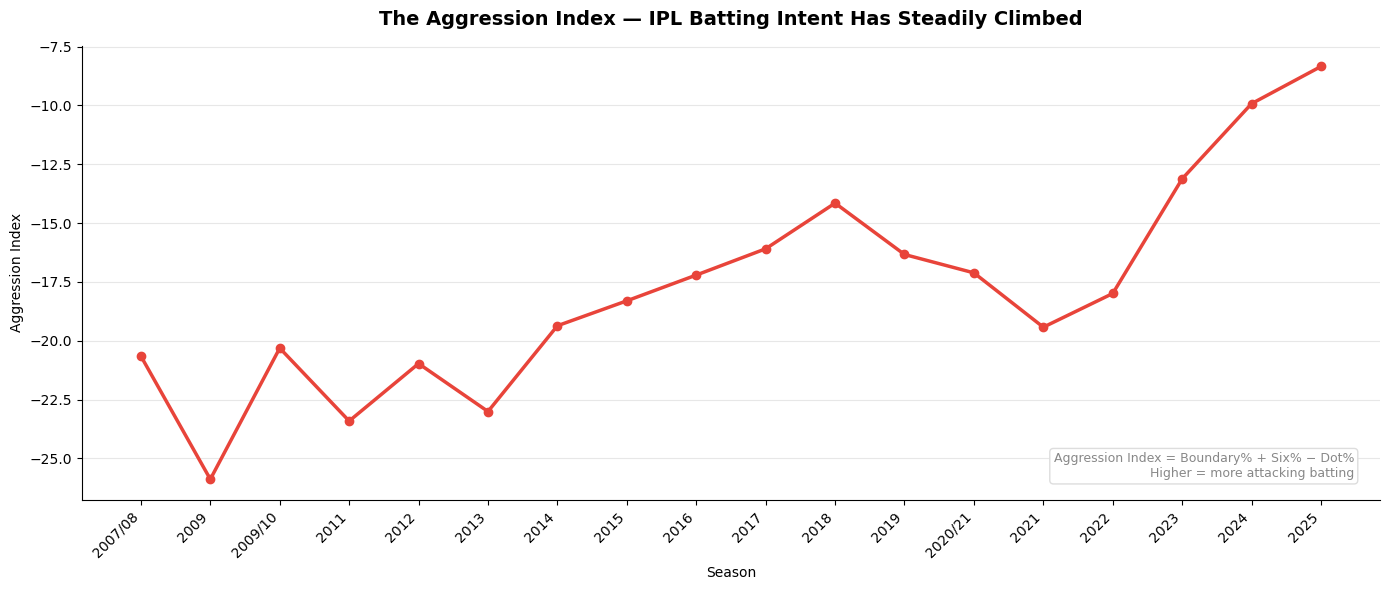

In [28]:
fig, ax = plt.subplots(figsize=(14, 6))

seasons = range(len(aggression))
season_labels = aggression.index

ax.plot(seasons, aggression['aggression_index'], color='#E8443A', linewidth=2.5, marker='o')

ax.set_xticks(seasons)
ax.set_xticklabels(season_labels, rotation=45, ha='right')
ax.set_xlabel('Season')
ax.set_ylabel('Aggression Index')
ax.set_title('The Aggression Index — IPL Batting Intent Has Steadily Climbed',
             fontsize=14, fontweight='bold', pad=15)

ax.text(0.98, 0.05, 'Aggression Index = Boundary% + Six% − Dot%\nHigher = more attacking batting',
        transform=ax.transAxes, fontsize=9, ha='right', color='#888888',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#DDDDDD'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('10_aggression_index.png', dpi=150)
plt.show()

# The Bowler's Side of the Story
The first 10 findings told the batting story. But every ball has two sides, if batsmen got more aggressive, what happened to the bowlers? Let's look at the other side of the revolution.

In [29]:
total_runs = deliveries_m.groupby('season')['total_runs'].sum()
total_balls = deliveries_m.groupby('season').size()
total_overs = total_balls / 6
economy_by_season = (total_runs / total_overs).sort_index()
print("Economy rate by season:")
print(economy_by_season.round(2))

Economy rate by season:
season
2007/08    7.98
2009       7.21
2009/10    7.81
2011       7.46
2012       7.58
2013       7.46
2014       7.94
2015       8.07
2016       8.03
2017       8.13
2018       8.36
2019       8.15
2020/21    8.00
2021       7.75
2022       8.17
2023       8.63
2024       9.11
2025       9.21
dtype: float64


## Finding 11: Economy Rate - Are Bowlers getting more expensive?
Economy rate measures how many runs a bowler gives per over. If batting got more aggrressive, this number should be climbing.

In [48]:
# Dismissal type breakdown by era
dismissals = deliveries_m[deliveries_m['dismissal_kind'].notna()]

dismissal_by_era = dismissals.groupby(['era', 'dismissal_kind']).size()
dismissal_totals = dismissals.groupby('era').size()
dismissal_pct = (dismissal_by_era / dismissal_totals * 100).round(1).unstack('era')

print(dismissal_pct)

era                    Early (2007-2015)  Recent (2016-2025)
dismissal_kind                                              
bowled                              18.7                16.1
caught                              59.4                64.4
caught and bowled                    2.9                 2.8
hit wicket                           0.1                 0.2
lbw                                  6.0                 6.2
obstructing the field                0.0                 0.0
retired hurt                         0.1                 0.1
retired out                          NaN                 0.1
run out                              9.6                 7.7
stumped                              3.3                 2.5


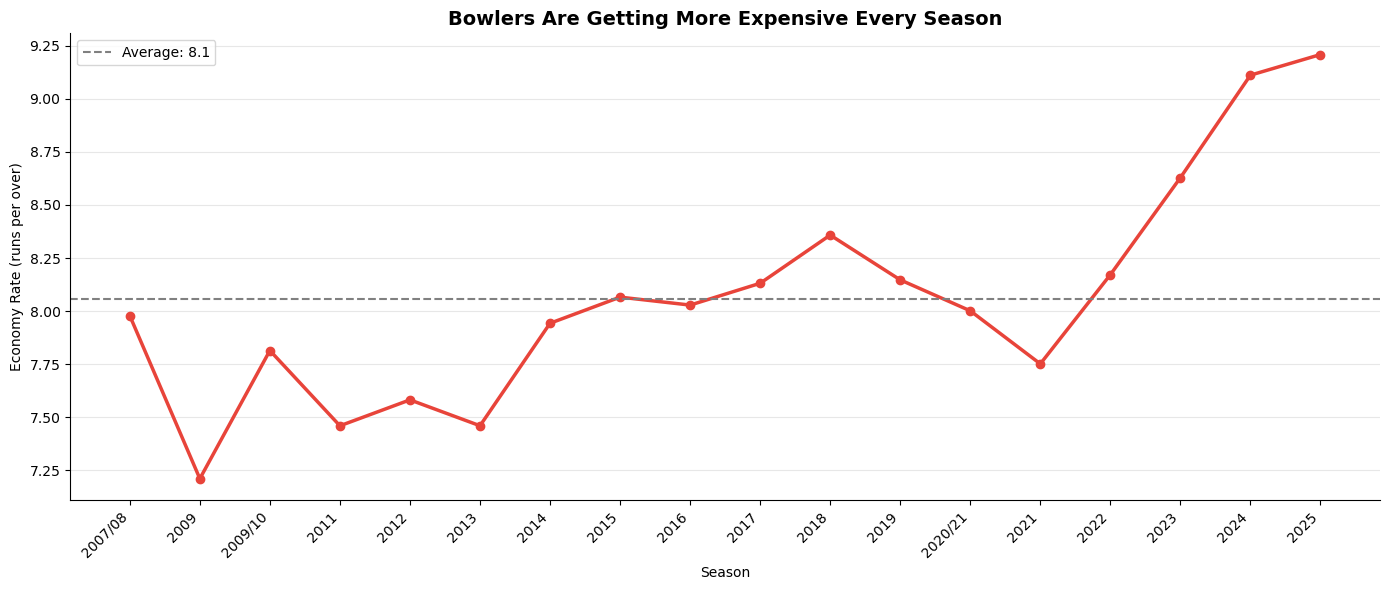

In [49]:
fig, ax = plt.subplots(figsize=(14, 6))

seasons = range(len(economy_by_season))
season_labels = economy_by_season.index

ax.plot(seasons, economy_by_season.values, marker='o', color='#E8443A', linewidth=2.5)

avg = economy_by_season.mean()
ax.axhline(y=avg, linestyle='--', color='gray', label=f'Average: {avg:.1f}')

ax.set_xticks(seasons)
ax.set_xticklabels(season_labels, rotation=45, ha='right')
ax.set_xlabel('Season')
ax.set_ylabel('Economy Rate (runs per over)')
ax.set_title('Bowlers Are Getting More Expensive Every Season', fontsize=14, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('11_economy_rate_by_season.png', dpi=150)
plt.show()


## Finding 12: How has the way changed get out changed?
If batsmen are swinging harder, we would expect more "caught" dimissals (ball goes in the air) and fewer "bowled" (defensive shots). Let's check.

In [50]:
types = ['caught', 'bowled', 'run out', 'lbw']
early_vals = [dismissal_pct.loc[t, 'Early (2007-2015)'] for t in types]
recent_vals = [dismissal_pct.loc[t, 'Recent (2016-2025)'] for t in types]

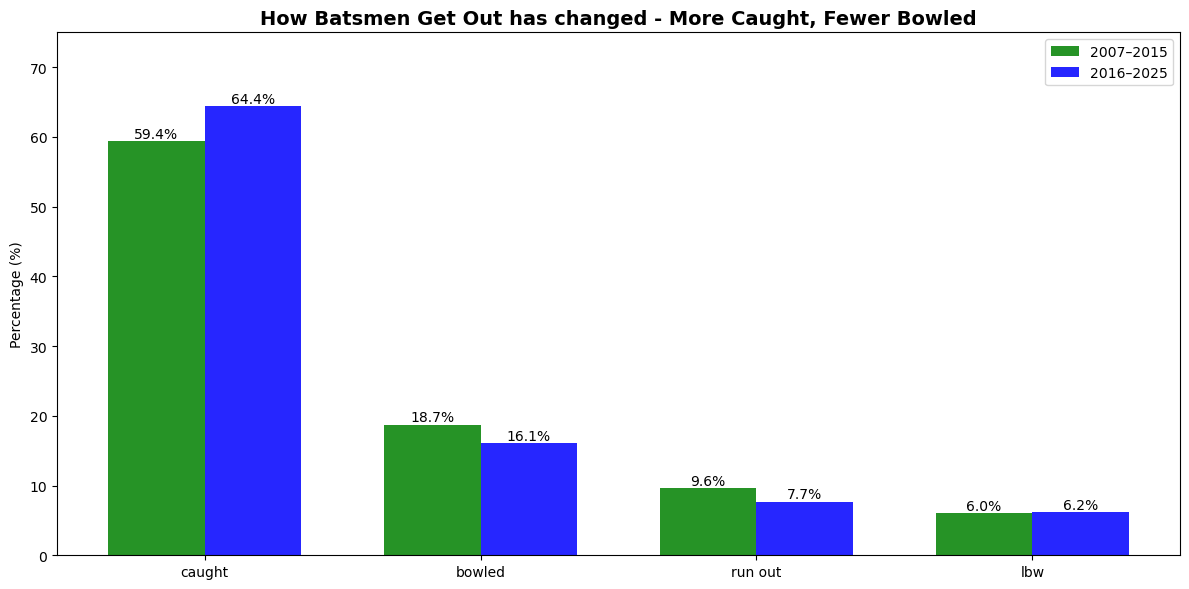

In [82]:
fig, ax = plt.subplots(figsize = (12, 6))
x = np.arange(len(types))
width = 0.35
bars_1 = ax.bar(x - width/2, early_vals, width, label='2007–2015', color='green', alpha=0.85)
bars_2 = ax.bar(x + width/2, recent_vals, width, label='2016–2025', color='blue', alpha=0.85)

for bar in bars_1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10)
for bar in bars_2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10)

ax.set_ylabel('Percentage (%)')
ax.set_title('How Batsmen Get Out has changed - More Caught, Fewer Bowled', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(types)
ax.legend()
ax.set_ylim(0, 75)

plt.tight_layout()
plt.savefig('12_dismissal_types_by_era.png', dpi=150)
plt.show()

## Summary
Over 18 IPL season, batting has been fundamentally reprogrammed. Batsmen converted dot balls into boundaries, especially in the powerplay, without getting out more often. This wasn't wasn't reckless. It was a skill upgrade. And bowlers paid the price, with economy rates climbing from 7.2 to 9.2 runs per over.